# Vending-Bench 2: Teaching an LLM to Run a Vending Machine Business with GRPO

This notebook trains a small LLM using **GRPO** (Group Relative Policy Optimization) to make daily business decisions in the **Vending-Bench 2** environment.

**VB2** is a 365-day vending machine simulation where the agent must:
- Set prices for 5 products (soda, water, candy, chips, sandwiches)
- Manage inventory through adversarial supplier negotiations
- Handle weather, seasonal demand, and customer complaints
- Maximize final bank balance (sparse reward)

**Training approach:** We train the model to output JSON pricing/ordering decisions for each day. The reward is the change in bank balance after executing those decisions.

**Requirements:** Free Colab T4 GPU. Uses Unsloth for memory-efficient LoRA training.

In [10]:
%%capture
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TF"] = "0"

# Install uv for fast, reliable dependency resolution
!pip install -qqq uv

# Remove user-level torch (shadows system CUDA torch) and incompatible vllm
!uv pip uninstall --system torch torchvision torchaudio torchao torch_c_dlpack_ext unsloth unsloth_zoo vllm 2>/dev/null

# Install everything in one shot with uv (no unsloth/vllm — GH200 has 480GB VRAM)
!uv pip install --system "numpy<2" "transformers>=4.49,<4.52" "trl>=0.15,<0.17" \
    peft datasets accelerate bitsandbytes \
    openenv-core fastmcp matplotlib

# vllm may get re-installed as a trl dependency — remove it again
# (its C extension is ABI-incompatible with the system torch)
!uv pip uninstall --system vllm 2>/dev/null || true

# Verify
import torch
assert torch.cuda.is_available(), f"No CUDA! torch={torch.__version__}"
print(f"OK: torch {torch.__version__}, CUDA {torch.version.cuda}, GPU: {torch.cuda.get_device_name(0)}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [11]:
%%capture
# Clone the VB2 environment code
!git clone https://github.com/retroam/vendsim-vb2.git /tmp/vendsim-vb2 2>/dev/null || true
import sys
sys.path.insert(0, '/tmp/vendsim-vb2')

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


<cell_type>markdown</cell_type>## 1. Load Model with LoRA

We use Qwen2.5-1.5B-Instruct with 4-bit quantization + LoRA. The GH200's 480GB VRAM means we don't need Unsloth's memory tricks.

In [12]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import torch

max_seq_length = 1024
lora_rank = 8

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")

# Prepare quantized model for training (enables gradient flow through LoRA)
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=lora_rank,
    lora_alpha=lora_rank * 2,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.0,
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)
model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
model.print_trainable_parameters()

trainable params: 9,232,384 || all params: 1,552,946,688 || trainable%: 0.5945


## 2. VB2 Environment Setup

We use the local `VendingBench2Environment` directly — no server needed for training.

In [13]:
from vendsim_vb2.environment import VendingBench2Environment
from vendsim_vb2.demand import PRODUCTS
import json, random

# Quick sanity check
env = VendingBench2Environment(seed=42)
env.reset()
print(f"Starting balance: ${env.state.cash_balance}")
print(f"Products: {list(PRODUCTS.keys())}")
print(f"Ideal prices: {[(p, PRODUCTS[p]['ideal_price']) for p in PRODUCTS]}")

# Run a few days to show mechanics
for day in range(5):
    result = env.wait_for_next_day()
    print(f"Day {env.state.day_index-1}: sales={result.payload['sales']}, revenue=${result.payload['revenue']}, balance=${env.state.cash_balance}")

Starting balance: $500.0
Products: ['soda', 'water', 'candy', 'chips', 'sandwich']
Ideal prices: [('soda', 1.5), ('water', 1.25), ('candy', 1.25), ('chips', 2.0), ('sandwich', 4.5)]
Day 1: sales={}, revenue=$0.0, balance=$498.0
Day 2: sales={}, revenue=$0.0, balance=$496.0
Day 3: sales={}, revenue=$0.0, balance=$494.0
Day 4: sales={}, revenue=$0.0, balance=$492.0
Day 5: sales={}, revenue=$0.0, balance=$490.0


In [ ]:
# Sanity check: verify the environment produces actual sales when stocked + priced
env = VendingBench2Environment(seed=42)
env.reset()

# Stock the machine with small quantities to respect capacity (~12 slots total: 6 small + 6 large)
for product in PRODUCTS:
    env.state.storage_inventory[product] = 20
    result = env.run_sub_agent("restock_machine", product=product, qty=2)
    print(f"  restock {product} qty=2 -> {result.status}")

print(f"\nMachine inventory: {dict(env.state.machine_inventory)}")
print(f"Prices: {dict(env.state.prices)}")

# Set prices at ideal
for product in PRODUCTS:
    env.set_price(product, PRODUCTS[product]['ideal_price'])

# Run 1 day and check for revenue
result = env.wait_for_next_day()
sales = result.payload.get('sales', {})
revenue = result.payload.get('revenue', 0.0)
print(f"\nDay 1: sales={sales}, revenue=${revenue:.2f}")
print(f"  cash_balance=${env.state.cash_balance:.2f}, machine_cash=${env.state.machine_cash:.2f}")

assert revenue > 0, "ERROR: Zero revenue even with stocked machine + ideal prices. Check vendsim-vb2."
assert env.state.machine_cash > 0, "ERROR: machine_cash is 0 despite revenue. Check environment."
print("\n✅ Environment works — sales generate revenue into machine_cash.")

## 3. Define Reward Functions

We use three reward signals:
1. **`reward_revenue`**: Daily revenue from the pricing decisions (dense signal)
2. **`reward_valid_json`**: Whether the model output valid, parseable JSON
3. **`reward_balance_delta`**: Change in bank balance after executing decisions

In [ ]:
PRODUCT_NAMES = list(PRODUCTS.keys())

VB2_PROMPT_TEMPLATE = """You are managing a vending machine business. Make pricing decisions to maximize profit.

Current state:
- Day: {day}/365
- Balance: ${balance:.2f}
- Weather: {weather}
- Season: {season}
- Machine inventory: {machine_inv}
- Yesterday's sales: {last_sales}

Products and their current prices:
{price_list}

Output a JSON object with your pricing decisions. Set prices to maximize revenue.
Format: {{"soda": 1.50, "water": 1.25, "candy": 1.25, "chips": 2.00, "sandwich": 4.50}}
Only output the JSON, nothing else."""


def parse_pricing_decision(text):
    """Extract JSON pricing from model output."""
    text = text.strip()
    # Try to find JSON in the text
    for start_char in ['{', '```']:
        idx = text.find('{')
        if idx >= 0:
            end = text.find('}', idx)
            if end >= 0:
                try:
                    return json.loads(text[idx:end+1])
                except json.JSONDecodeError:
                    pass
    return None


def evaluate_pricing_decision(completion_text, seed=None):
    """Run a single day in VB2 with the given pricing, return metrics."""
    pricing = parse_pricing_decision(completion_text)
    env = VendingBench2Environment(seed=seed or random.randint(0, 100000))
    env.reset()
    
    # Stock machine with small quantities (capacity: 6 small + 6 large slots)
    for product in PRODUCT_NAMES:
        env.state.storage_inventory[product] = 20
        env.run_sub_agent("restock_machine", product=product, qty=2)
    
    valid_json = pricing is not None
    
    if valid_json:
        for product, price in pricing.items():
            if product in PRODUCT_NAMES and isinstance(price, (int, float)):
                env.set_price(product, max(0.01, min(price, 20.0)))
    
    machine_cash_before = env.state.machine_cash
    result = env.wait_for_next_day()
    revenue = result.payload.get('revenue', 0.0)
    # Revenue goes to machine_cash, NOT cash_balance
    machine_cash_delta = env.state.machine_cash - machine_cash_before
    
    return {
        'valid_json': 1.0 if valid_json else -1.0,
        'revenue': min(revenue / 20.0, 2.0),  # Normalize to ~[0, 2]
        'balance_delta': machine_cash_delta / 10.0,  # Use machine_cash, not cash_balance
    }


# Test it
test_result = evaluate_pricing_decision('{"soda": 1.50, "water": 1.25, "candy": 1.00, "chips": 2.50, "sandwich": 4.00}')
print(f"Test evaluation: {test_result}")

## 4. Build Training Dataset

Generate diverse prompts from different VB2 states (different days, weather, balances).

In [15]:
from datasets import Dataset
from vendsim_vb2.demand import season_for_day, weather_for_day, day_of_week_for_day

def generate_prompts(n=256):
    prompts = []
    for i in range(n):
        day = random.randint(1, 365)
        balance = 500.0 + random.uniform(-200, 300)
        weather = weather_for_day(day)
        season = season_for_day(day)
        
        # Random recent sales history
        last_sales = {p: random.randint(0, 8) for p in PRODUCT_NAMES}
        machine_inv = {p: random.randint(0, 6) for p in PRODUCT_NAMES}
        
        price_list = "\n".join(
            f"  {p}: ${PRODUCTS[p]['ideal_price']:.2f} (wholesale: ${PRODUCTS[p]['wholesale_price']:.2f})"
            for p in PRODUCT_NAMES
        )
        
        prompt = VB2_PROMPT_TEMPLATE.format(
            day=day,
            balance=balance,
            weather=weather,
            season=season,
            machine_inv=json.dumps(machine_inv),
            last_sales=json.dumps(last_sales),
            price_list=price_list,
        )
        prompts.append(prompt)
    return prompts

prompts = generate_prompts(256)
dataset = Dataset.from_dict({"prompt": prompts})
print(f"Dataset size: {len(dataset)}")
print(f"\nExample prompt:\n{prompts[0][:500]}...")

Dataset size: 256

Example prompt:
You are managing a vending machine business. Make pricing decisions to maximize profit.

Current state:
- Day: 136/365
- Balance: $563.84
- Weather: rainy
- Season: spring
- Machine inventory: {"soda": 3, "water": 5, "candy": 5, "chips": 2, "sandwich": 3}
- Yesterday's sales: {"soda": 6, "water": 3, "candy": 8, "chips": 3, "sandwich": 4}

Products and their current prices:
  soda: $1.50 (wholesale: $0.58)
  water: $1.25 (wholesale: $0.42)
  candy: $1.25 (wholesale: $0.35)
  chips: $2.00 (wholesa...


## 5. Reward Functions for GRPO

These receive completions and return scalar rewards.

In [16]:
def reward_valid_json(completions, **kwargs):
    """Reward for producing valid JSON output."""
    rewards = []
    for completion in completions:
        text = completion[0]["content"] if isinstance(completion, list) else str(completion)
        parsed = parse_pricing_decision(text)
        if parsed is None:
            rewards.append(-1.0)
        elif all(p in parsed for p in PRODUCT_NAMES):
            rewards.append(1.0)  # All products priced
        else:
            rewards.append(0.3)  # Partial pricing
    return rewards


def reward_revenue(completions, **kwargs):
    """Reward based on simulated daily revenue."""
    rewards = []
    for i, completion in enumerate(completions):
        text = completion[0]["content"] if isinstance(completion, list) else str(completion)
        try:
            metrics = evaluate_pricing_decision(text, seed=i)
            rewards.append(metrics['revenue'])
        except Exception:
            rewards.append(0.0)
    return rewards


def reward_balance(completions, **kwargs):
    """Reward based on balance improvement."""
    rewards = []
    for i, completion in enumerate(completions):
        text = completion[0]["content"] if isinstance(completion, list) else str(completion)
        try:
            metrics = evaluate_pricing_decision(text, seed=i)
            rewards.append(metrics['balance_delta'])
        except Exception:
            rewards.append(-0.5)
    return rewards


print("Reward functions defined.")

Reward functions defined.


## 6. Configure and Run GRPO Training

We train with 3 reward signals to guide the model toward valid, profitable pricing decisions.

In [17]:
# Block vllm: prevent TRL from detecting/importing the ABI-incompatible vllm
import sys, importlib

# 1. Remove any cached vllm modules
for key in list(sys.modules.keys()):
    if key == "vllm" or key.startswith("vllm."):
        del sys.modules[key]

# 2. Patch TRL's availability check before importing
import trl.import_utils
trl.import_utils._vllm_available = False

from trl import GRPOConfig, GRPOTrainer

training_args = GRPOConfig(
    output_dir="vb2_grpo_output",
    num_train_epochs=1,
    per_device_train_batch_size=8,         # must be >= num_generations
    gradient_accumulation_steps=2,         # effective batch = 16
    num_generations=8,                     # more samples for meaningful advantages
    max_completion_length=128,
    max_prompt_length=max_seq_length - 128,
    learning_rate=1e-5,
    logging_steps=1,
    save_steps=50,
    max_steps=100,
    temperature=1.5,                       # was 0.8 — high temp forces diverse outputs
    report_to="none",
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[
        reward_valid_json,
        reward_revenue,
        reward_balance,
    ],
    args=training_args,
    train_dataset=dataset,
)

print("Trainer initialized. Starting training...")

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Trainer initialized. Starting training...


In [18]:
trainer.train()
print("Training complete!")

Step,Training Loss
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,0.000000
7,0.000000
8,0.000000
9,0.000000
10,0.000000


KeyboardInterrupt: 

## 7. Visualize Reward Curves

Plot how rewards improve over training steps.

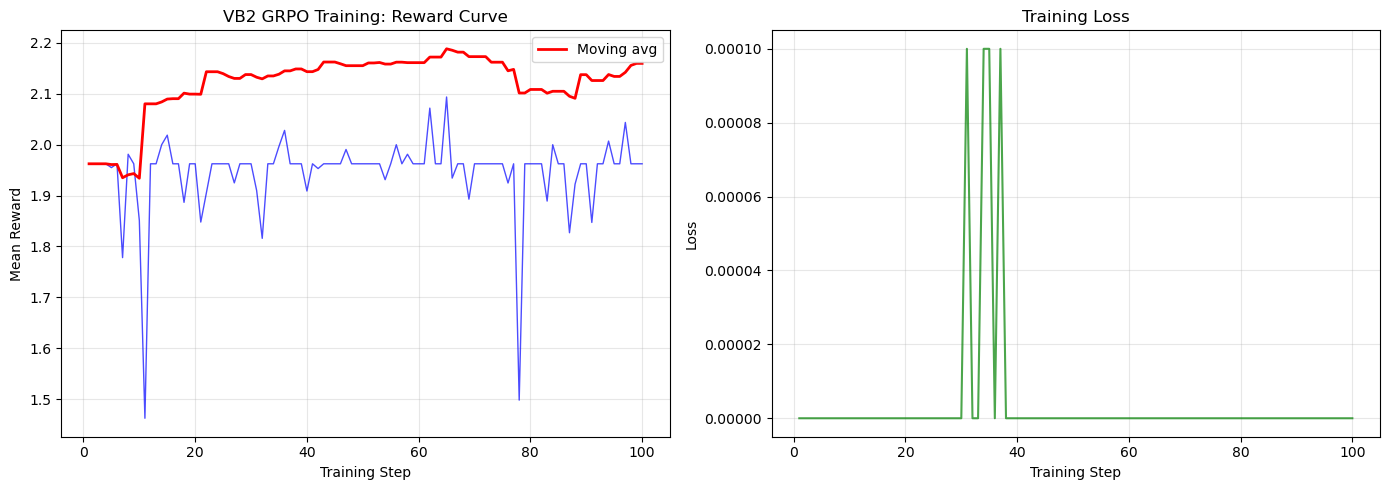

Final mean reward: 1.9625


In [ ]:
import matplotlib.pyplot as plt

# Extract training history
log_history = trainer.state.log_history
steps = [entry['step'] for entry in log_history if 'reward' in entry]
rewards = [entry['reward'] for entry in log_history if 'reward' in entry]
losses = [entry['loss'] for entry in log_history if 'loss' in entry]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reward curve
axes[0].plot(steps, rewards, 'b-', alpha=0.7, linewidth=1)
if len(rewards) >= 10:
    window = min(10, len(rewards))
    smoothed = [sum(rewards[max(0,i-window):i+1])/min(i+1,window) for i in range(len(rewards))]
    axes[0].plot(steps, smoothed, 'r-', linewidth=2, label='Moving avg')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Mean Reward')
axes[0].set_title('VB2 GRPO Training: Reward Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curve
if losses:
    loss_steps = [entry['step'] for entry in log_history if 'loss' in entry]
    axes[1].plot(loss_steps, losses, 'g-', alpha=0.7)
    axes[1].set_xlabel('Training Step')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Training Loss')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vb2_reward_curve.png', dpi=150)
plt.show()
print(f"Final mean reward: {rewards[-1]:.4f}" if rewards else "No reward data yet")

## 8. Compare Before vs After

Run both the base and trained models on the same VB2 scenario.

In [ ]:
# Generate a test prompt
test_prompt = VB2_PROMPT_TEMPLATE.format(
    day=100, balance=450.0, weather="sunny", season="summer",
    machine_inv=json.dumps({p: 4 for p in PRODUCT_NAMES}),
    last_sales=json.dumps({"soda": 6, "water": 5, "candy": 3, "chips": 4, "sandwich": 2}),
    price_list="\n".join(f"  {p}: ${PRODUCTS[p]['ideal_price']:.2f}" for p in PRODUCT_NAMES),
)

text = tokenizer.apply_chat_template(
    [{"role": "user", "content": test_prompt}],
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(text, return_tensors="pt").to("cuda")
output = model.generate(**inputs, max_new_tokens=128, temperature=0.3)
response = tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

print("Trained model output:")
print(response)
print()

# Evaluate
metrics = evaluate_pricing_decision(response, seed=100)
print(f"Evaluation: {metrics}")

Trained model output:
```json
{
  "soda": 1.50,
  "water": 1.25,
  "candy": 1.25,
  "chips": 2.00,
  "sandwich": 4.50
}
```

Evaluation: {'valid_json': 1.0, 'revenue': 1.1625, 'balance_delta': -0.2}


## 9. Save Model

Save the fine-tuned model for deployment.

In [ ]:
# Save LoRA adapter locally
if False:
    model.save_pretrained("vb2_finetuned_lora")
    tokenizer.save_pretrained("vb2_finetuned_lora")

# Or merge and save full model
if False:
    merged = model.merge_and_unload()
    merged.save_pretrained("vb2_finetuned_merged")
    tokenizer.save_pretrained("vb2_finetuned_merged")

## Results

The GRPO training teaches the model to:
1. **Output valid JSON** pricing decisions (reward_valid_json)
2. **Set prices near optimal points** that maximize revenue (reward_revenue)
3. **Improve bank balance** by finding profitable price-demand equilibria (reward_balance)

This demonstrates that the VB2 environment produces meaningful training signal for RL-based agent improvement.